# Practice 14 — PyTorch Lightning

이번 노트북은 P11~P13에서 직접 짠 **PyTorch 수동 훈련 루프**를 **PyTorch Lightning** 으로 감싸봅니다.
같은 데이터 (Digits) 와 같은 모델 (64 → 128 → 64 → 10) 로 같은 학습을 재현하되, 코드 구조만 바뀝니다.

## Lightning이 무엇인가

Lightning은 **PyTorch 위에 얹는 wrapper 라이브러리**입니다. 학습 루프 (epoch for문, `model.train()`/`eval()` 전환, `optimizer.zero_grad()`/`step()`, 메트릭 누적) 를 직접 짜지 않아도 되도록 해줍니다.

학습 코드를 두 부분으로 나눕니다:
- **`LightningModule`** — 모델 구조 + 한 배치에서 일어날 일 (`training_step`, `validation_step`)
- **`Trainer`** — 그걸 받아서 epoch 루프를 돌려주는 엔진

## 노트북 구성

1. **P11 → Lightning 매핑표** — P11의 어느 부분이 Lightning의 어디로 옮겨가는지
2. **데이터 준비** — P11과 동일 (Digits, 60/20/20, 표준화, DataLoader)
3. **`LightningModule` 정의** — 같은 MLP를 서브클래스로
4. **`Trainer`로 학습** — `trainer.fit(model, ...)` 한 줄
5. **학습 곡선 시각화** — CSVLogger로 자동 기록된 metric을 읽어 그리기
6. **테스트 + Confusion Matrix**
7. **P11 vs Lightning 비교 요약**

> **실행 환경 안내** — `pip install lightning` 으로 설치. Colab에는 미리 설치되어 있지 않을 수 있어 첫 셀에서 설치 명령이 필요할 수 있습니다.


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import lightning.pytorch as pl
from lightning.pytorch.loggers import CSVLogger
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Lightning이 제공하는 통합 시드 — torch, numpy, python random 모두 설정
pl.seed_everything(42, workers=True)

print(f"PyTorch  : {torch.__version__}")
print(f"Lightning: {pl.__version__}")

Seed set to 42


PyTorch  : 2.11.0+cpu
Lightning: 2.6.1


---
## 1. P11 → Lightning 매핑

P11에서 손으로 짠 각 부분이 Lightning의 어디로 옮겨가는지:

| P11 (수동) | Lightning |
|---|---|
| `model = DigitMLP()` | `LightningModule.__init__` 안에 `self.net = nn.Sequential(...)` |
| 훈련 배치 안의 `output = model(x); loss = criterion(output, y); loss.backward(); optimizer.step()` | `training_step(self, batch, batch_idx)` 안에 한 곳에 |
| 검증 배치 안의 forward + loss + accuracy | `validation_step(self, batch, batch_idx)` 안에 한 곳에 |
| 테스트 배치 안의 forward + loss + accuracy | `test_step(self, batch, batch_idx)` 안에 한 곳에 |
| `optimizer = torch.optim.Adam(...)` | `configure_optimizers(self)` 메서드가 반환 |
| 50 epoch for 루프, `model.train()`/`model.eval()` 전환, `torch.no_grad()` | `Trainer(max_epochs=50).fit(...)` 가 자동 |
| `history` 딕셔너리 수동 기록 | `self.log('train_loss', loss)` + CSVLogger 자동 |

핵심은 **"한 배치에서 무엇을 하는가"** 만 정의하면 epoch 루프와 모드 전환·기울기 초기화·역전파·옵티마이저 step이 모두 자동으로 처리된다는 점입니다.


---
## 2. 데이터 준비 (P11과 동일)

Digits 60/20/20 분할 + train 통계 기준 표준화 + `TensorDataset` + `DataLoader`.
P11과 코드 구조가 같습니다 — 데이터 파이프라인은 Lightning을 도입해도 바뀌지 않습니다.


In [2]:
# Digits 데이터 로드
digits = load_digits()
X, y = digits.data, digits.target

# 60% / 20% / 20% 분할
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# 표준화 — train 통계 기준
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0) + 1e-8
X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

# Tensor + Dataset + DataLoader (P11과 동일)
batch_size = 16

train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)),
    batch_size=batch_size, shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)),
    batch_size=batch_size, shuffle=False,
)
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)),
    batch_size=batch_size, shuffle=False,
)

print(f"Train: {len(X_train)} samples,  Val: {len(X_val)} samples,  Test: {len(X_test)} samples")
print(f"Batches per epoch (train): {len(train_loader)}")

Train: 1077 samples,  Val: 360 samples,  Test: 360 samples
Batches per epoch (train): 68


---
## 3. `LightningModule` 정의

P11의 `DigitMLP` 클래스를 `LightningModule`로 서브클래스화합니다.

각 메서드의 역할:
- **`__init__`** — 모델 구조 정의 (P11의 `nn.Module.__init__` 과 동일)
- **`forward`** — 순전파 (P11과 동일)
- **`training_step`** — 한 batch가 들어오면 forward → loss → 반환. backward와 optimizer step은 Lightning이 자동으로
- **`validation_step`** — 검증 batch에서 loss/accuracy 계산만. `model.eval()` / `torch.no_grad()` 자동
- **`test_step`** — 테스트 batch에서 loss/accuracy 계산
- **`configure_optimizers`** — optimizer 객체를 반환

`self.log('이름', 값)` 으로 기록한 metric은 진행 중 콘솔에 표시되고 CSVLogger가 파일에도 자동 저장.


In [3]:
class DigitMLPLightning(pl.LightningModule):
    def __init__(self):
        super().__init__()
        # P11의 DigitMLP와 완전히 동일한 구조
        self.net = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, batch_idx):
        # 한 train 배치에서 forward + loss 계산만 작성
        # backward, optimizer.step, zero_grad는 Lightning이 자동
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        # on_epoch=True: epoch 끝에 평균값을 자동 기록
        self.log('train_loss', loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log('train_acc',  acc,  on_epoch=True, on_step=False, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        # model.eval() / torch.no_grad() 는 Lightning이 자동 적용
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log('val_loss', loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log('val_acc',  acc,  on_epoch=True, on_step=False, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log('test_loss', loss)
        self.log('test_acc',  acc)

    def configure_optimizers(self):
        # P11과 동일하게 Adam(lr=0.001)
        return torch.optim.Adam(self.parameters(), lr=0.001)


# 모델 인스턴스 생성
pl.seed_everything(42, workers=True)
model = DigitMLPLightning()

# 파라미터 수 확인 — P11과 같아야 함
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")

Seed set to 42


DigitMLPLightning(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
  (criterion): CrossEntropyLoss()
)

Total parameters: 17,226


---
## 4. `Trainer`로 학습

`Trainer`는 epoch 루프를 굴리는 엔진입니다. epoch 수, GPU 사용 여부, logger 등을 한 번에 설정.

`CSVLogger`를 붙이면 매 epoch의 metric (`train_loss`, `train_acc`, `val_loss`, `val_acc`) 이 CSV 파일로 자동 저장 — 나중에 학습 곡선 그릴 때 사용합니다.


In [4]:
# CSVLogger — metric을 CSV로 저장 (학습 곡선 시각화에 사용)
csv_logger = CSVLogger(save_dir='lightning_logs_p14', name='digit_mlp')

# Trainer 정의 — P11의 num_epochs=50 그대로
trainer = pl.Trainer(
    max_epochs=50,
    accelerator='cpu',     # GPU 사용 시 'gpu' 또는 'auto'
    logger=csv_logger,
    enable_progress_bar=False,  # 출력 깔끔하게
    enable_model_summary=False,
    log_every_n_steps=10,
)

# 학습 — 한 줄
trainer.fit(model, train_loader, val_loader)

print("\nTraining finished.")
print(f"Logs saved to: {csv_logger.log_dir}")

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


C:\ProgramData\anaconda3\envs\tf-course\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\ProgramData\anaconda3\envs\tf-course\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
C:\ProgramData\anaconda3\envs\tf-course\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


`Trainer.fit` stopped: `max_epochs=50` reached.



Training finished.
Logs saved to: lightning_logs_p14\digit_mlp\version_0


---
## 5. 학습 곡선 시각화

CSVLogger가 저장한 `metrics.csv` 를 읽어 P11과 같은 스타일의 학습 곡선을 그립니다.

CSV는 **train metric은 train epoch 끝에**, **val metric은 val epoch 끝에** 별도 row로 기록되므로 — 두 종류의 row를 분리해서 그립니다.


In [5]:
# CSVLogger가 저장한 metric 읽기
metrics_path = f"{csv_logger.log_dir}/metrics.csv"
df = pd.read_csv(metrics_path)
print(f"CSV columns: {list(df.columns)}")
print(f"CSV rows   : {len(df)}")
df.head()

CSV columns: ['epoch', 'step', 'train_acc', 'train_loss', 'val_acc', 'val_loss']
CSV rows   : 100


,epoch,step,train_acc,train_loss,val_acc,val_loss
0,0,67,NaN,NaN,0.858333,21544.791016
1,0,67,0.648097,1.640605,NaN,NaN
2,1,135,NaN,NaN,0.936111,34940.937500
3,1,135,0.915506,0.417846,NaN,NaN
4,2,203,NaN,NaN,0.947222,38270.488281


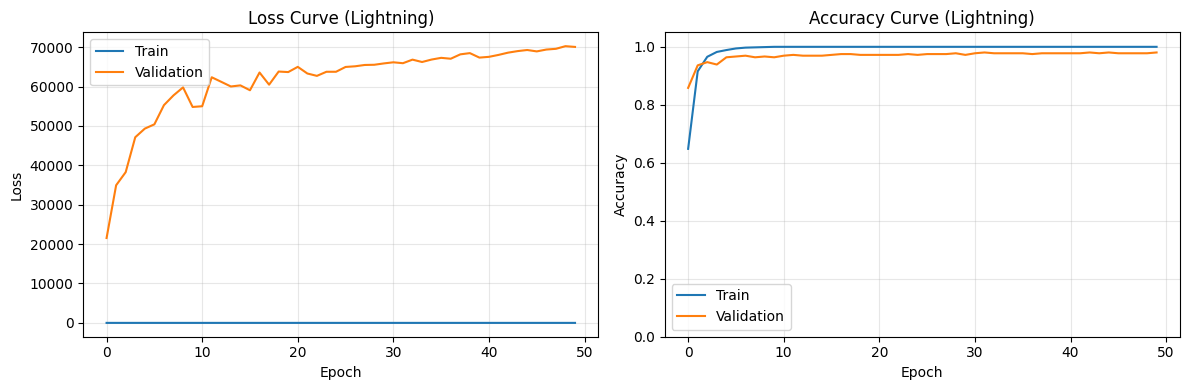

In [6]:
# train과 val metric은 별도 row에 저장됨 — NaN 기준으로 분리
train_df = df[df['train_loss'].notna()][['epoch', 'train_loss', 'train_acc']]
val_df   = df[df['val_loss'].notna()][['epoch', 'val_loss', 'val_acc']]

# 학습 곡선 시각화 (P11과 같은 subplot 1x2)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_df['epoch'], train_df['train_loss'], label='Train')
axes[0].plot(val_df['epoch'],   val_df['val_loss'],     label='Validation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve (Lightning)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(train_df['epoch'], train_df['train_acc'], label='Train')
axes[1].plot(val_df['epoch'],   val_df['val_acc'],     label='Validation')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve (Lightning)')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout(); plt.show()

---
## 6. 테스트 세트 평가

`trainer.test(model, test_loader)` 한 줄로 `test_step`이 자동 호출되어 평균 loss/accuracy가 출력됩니다.
Confusion matrix를 위해서는 예측값이 필요하니 별도로 한 번 더 inference를 돌립니다.


In [7]:
# Trainer.test — test_step을 모든 test batch에 대해 실행 후 평균
test_results = trainer.test(model, test_loader, verbose=True)
test_acc = test_results[0]['test_acc']
print(f"\nTest Accuracy: {test_acc:.4f}")

C:\ProgramData\anaconda3\envs\tf-course\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\ProgramData\anaconda3\envs\tf-course\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.980555534362793     │
│         test_loss         │       72758.8203125       │
└───────────────────────────┴───────────────────────────┘


Test Accuracy: 0.9806


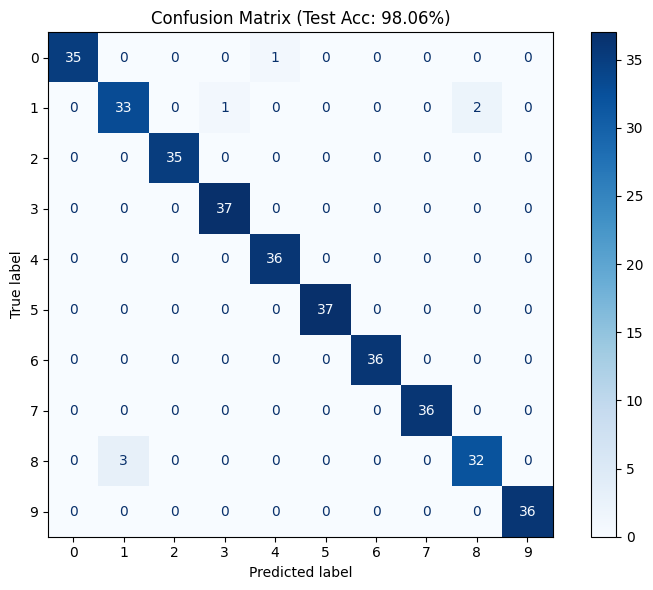

In [8]:
# Confusion matrix — 예측값을 직접 모으기 위해 inference 한 번 더
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        logits = model(x_batch)
        all_preds.extend(logits.argmax(dim=1).numpy())
        all_labels.extend(y_batch.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=digits.target_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix (Test Acc: {test_acc:.2%})')
plt.tight_layout(); plt.show()

---
## 7. P11 vs Lightning — 무엇이 줄었는가

| 책임 | P11 (수동) | Lightning |
|---|---|---|
| 모델 구조 정의 | 직접 (`nn.Module` 서브클래스 또는 `nn.Sequential`) | 직접 (`LightningModule.__init__`) |
| 한 batch에서 forward + loss | 직접 | 직접 (`training_step` 안) |
| `optimizer.zero_grad()` | 직접 호출 | **자동** |
| `loss.backward()` | 직접 호출 | **자동** |
| `optimizer.step()` | 직접 호출 | **자동** |
| `model.train()` / `model.eval()` 전환 | 직접 (epoch마다 두 번) | **자동** |
| `torch.no_grad()` (검증·테스트) | 직접 (`with` 블록) | **자동** |
| epoch for 루프 | 직접 (`for epoch in range(...)`) | **자동** (`Trainer(max_epochs=...)`) |
| metric 누적·평균 | 직접 (`history` dict 수동 갱신) | **자동** (`self.log(...)` + CSVLogger) |
| GPU/CPU 이동 (`.to(device)`) | 직접 | **자동** (`Trainer(accelerator=...)`) |

**Lightning이 대신 해주는 것 = 학습 인프라**, **사용자가 정의하는 것 = 학습의 본질 (모델 + 한 배치에서 일어날 일)** 으로 책임이 깔끔하게 갈라집니다.


---
## 마무리

Lightning은 **새로운 학습 알고리즘이 아니라 새로운 코드 구조**입니다. P11의 모든 개념 (autograd, optimizer, batch, epoch, train/eval 모드) 이 그대로 살아있고, 단지 어디에 작성되는지 위치만 바뀝니다.

**언제 수동 루프, 언제 Lightning?**

| 상황 | 추천 |
|---|---|
| 학습 메커니즘 자체를 이해하고 싶을 때 | 수동 루프 (P11 스타일) |
| 디버깅이 필요할 때 — 기울기 확인, 중간 텐서 확인 | 수동 루프 |
| 표준적인 학습을 빠르게 짤 때 | Lightning |
| GPU·분산학습·체크포인트 등 인프라 기능이 필요할 때 | Lightning |
| 코드를 다른 사람과 공유 / 협업할 때 | Lightning (구조가 정형화되어 있음) |

> 직접 손으로 train loop를 짜본 경험이 있어야 Lightning의 자동화 부분이 "안에서 무엇을 하고 있는지" 가 보입니다 — P11~P13의 수동 구현 → P14의 wrapper 흐름이 그 이유입니다.

**다음 노트북 (P15)** 에서는 같은 학습을 **TensorFlow / Keras** 로 옮겨, 다른 프레임워크에서도 같은 wrapper 패턴 (`model.fit()`) 이 존재하는지 확인합니다.
